In [1]:
# Cell 1 — load cleaned master dataframe
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("../data/master_df_clean.csv")
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

# Create outputs folder if not exists
os.makedirs("../outputs", exist_ok=True)

print("Data loaded:", df.shape)
print("Churn distribution:\n", df["churned"].value_counts())

Data loaded: (113422, 25)
Churn distribution:
 churned
1    80157
0    33265
Name: count, dtype: int64


C:\Users\FAYAS\AppData\Local\Temp\ipykernel_19084\1847477621.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_churn.values * 100, y=category_churn.index, palette="RdYlGn_r")


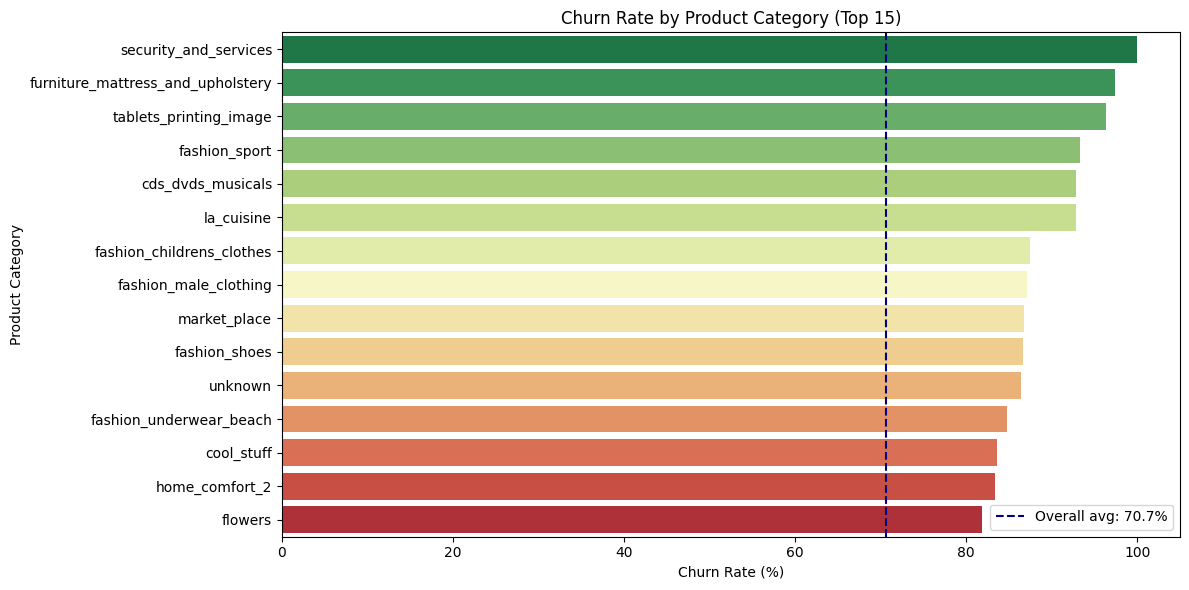

Chart 1 saved ✓


In [2]:
# Cell 2 — Chart 1: Churn rate by product category
plt.figure(figsize=(12, 6))

category_churn = df.groupby("product_category_name_english")["churned"].mean().sort_values(ascending=False).head(15)

sns.barplot(x=category_churn.values * 100, y=category_churn.index, palette="RdYlGn_r")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Product Category")
plt.title("Churn Rate by Product Category (Top 15)")
plt.axvline(x=df["churned"].mean() * 100, color="navy", linestyle="--", label=f"Overall avg: {df['churned'].mean()*100:.1f}%")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/chart1_churn_by_category.png", dpi=150)
plt.show()
print("Chart 1 saved ✓")

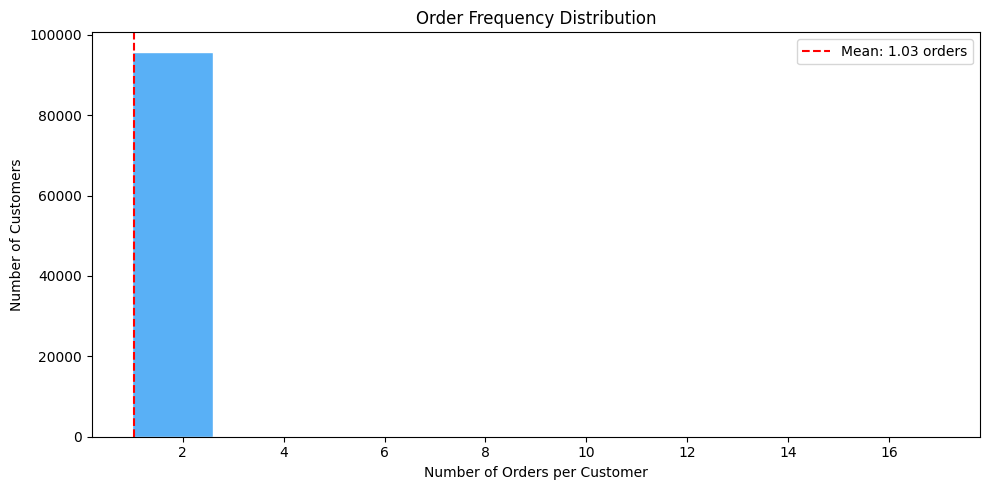

Chart 2 saved ✓
Average orders per customer: 1.03


In [3]:
# Cell 3 — Chart 2: Order frequency distribution
plt.figure(figsize=(10, 5))

order_freq = df.groupby("customer_unique_id")["order_id"].nunique()

sns.histplot(order_freq, bins=10, color="#2196F3", edgecolor="white")
plt.xlabel("Number of Orders per Customer")
plt.ylabel("Number of Customers")
plt.title("Order Frequency Distribution")
plt.axvline(x=order_freq.mean(), color="red", linestyle="--", label=f"Mean: {order_freq.mean():.2f} orders")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/chart2_order_frequency.png", dpi=150)
plt.show()
print("Chart 2 saved ✓")
print("Average orders per customer:", round(order_freq.mean(), 2))

C:\Users\FAYAS\AppData\Local\Temp\ipykernel_19084\1119915301.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_churn, x="churned_label", y="total_payment",


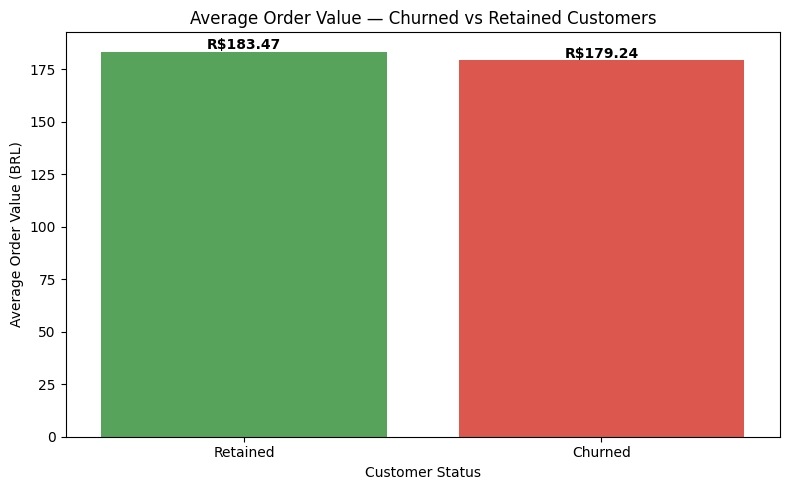

Chart 3 saved ✓


In [4]:
# Cell 4 — Chart 3: Revenue comparison churned vs retained
plt.figure(figsize=(8, 5))

revenue_by_churn = df.groupby("churned")["total_payment"].mean().reset_index()
revenue_by_churn["churned_label"] = revenue_by_churn["churned"].map({0: "Retained", 1: "Churned"})

sns.barplot(data=revenue_by_churn, x="churned_label", y="total_payment", 
            palette={"Retained": "#4CAF50", "Churned": "#F44336"})
plt.xlabel("Customer Status")
plt.ylabel("Average Order Value (BRL)")
plt.title("Average Order Value — Churned vs Retained Customers")
for i, row in revenue_by_churn.iterrows():
    plt.text(i, row["total_payment"] + 1, f"R${row['total_payment']:.2f}", 
             ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/chart3_revenue_churn.png", dpi=150)
plt.show()
print("Chart 3 saved ✓")

C:\Users\FAYAS\AppData\Local\Temp\ipykernel_19084\1911139842.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=review_churn, x="review_score", y="churned", palette="RdYlGn_r")


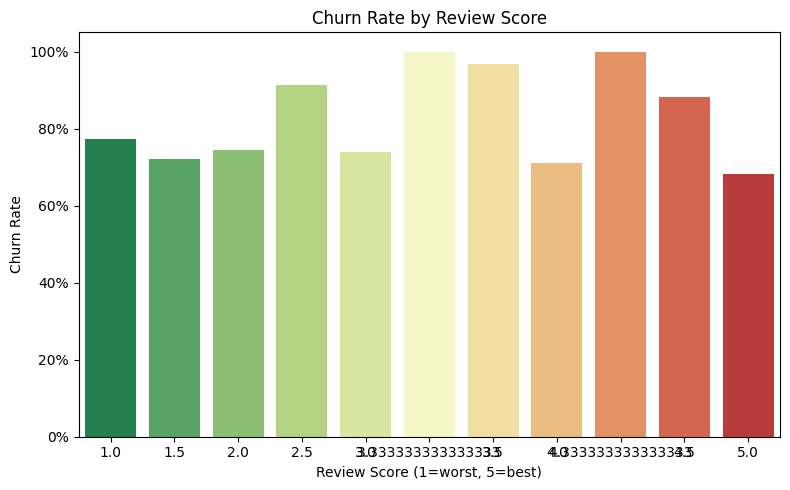

Chart 4 saved ✓


In [5]:
# Cell 5 — Chart 4: Review score vs churn rate
plt.figure(figsize=(8, 5))

review_churn = df.groupby("review_score")["churned"].mean().reset_index()

sns.barplot(data=review_churn, x="review_score", y="churned", palette="RdYlGn_r")
plt.xlabel("Review Score (1=worst, 5=best)")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Review Score")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
plt.tight_layout()
plt.savefig("../outputs/chart4_review_vs_churn.png", dpi=150)
plt.show()
print("Chart 4 saved ✓")

C:\Users\FAYAS\AppData\Local\Temp\ipykernel_19084\1600347051.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_churn, x="payment_type", y="churned", palette="Blues_r")


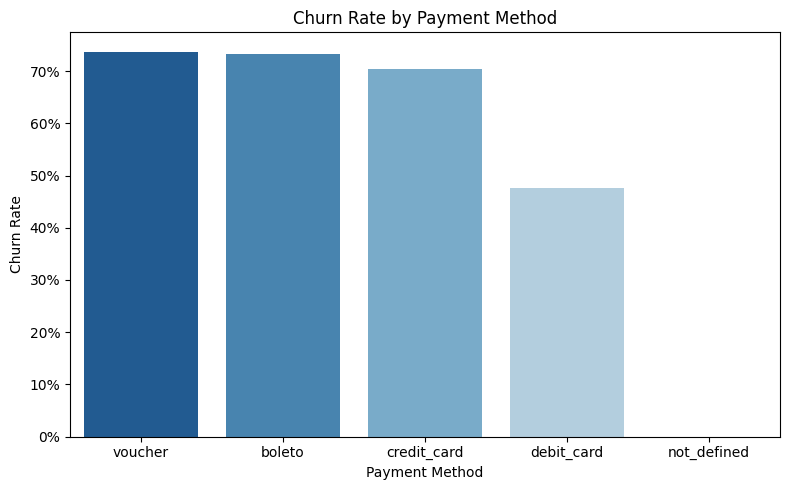

Chart 5 saved ✓


In [6]:
# Cell 6 — Chart 5: Payment method vs churn rate
plt.figure(figsize=(8, 5))

payment_churn = df.groupby("payment_type")["churned"].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=payment_churn, x="payment_type", y="churned", palette="Blues_r")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Payment Method")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
plt.tight_layout()
plt.savefig("../outputs/chart5_payment_vs_churn.png", dpi=150)
plt.show()
print("Chart 5 saved ✓")

In [7]:
# Cell 7 — confirm all outputs saved
import os
files = os.listdir("../outputs")
print("Files in outputs folder:")
for f in files:
    print(" ✓", f)


Files in outputs folder:
 ✓ chart1_churn_by_category.png
 ✓ chart2_order_frequency.png
 ✓ chart3_revenue_churn.png
 ✓ chart4_review_vs_churn.png
 ✓ chart5_payment_vs_churn.png
